In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
df = pd.read_csv('Customer Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

#replacing blanks with 0 as tenure is 0 and no total charges are recorded

In [14]:
df["TotalCharges"] = df["TotalCharges"].replace(" ",0)
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [19]:
df.isnull().sum().sum()

np.int64(0)

In [20]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [22]:
df["customerID"].duplicated().sum()

np.int64(0)

In [26]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"

        df['SeniorCitizen'] = df["SeniorCitizen"].apply(conv)
                                                    

#converted 0 and 1 values  of senior citizen to yes/no to make it easier to understand

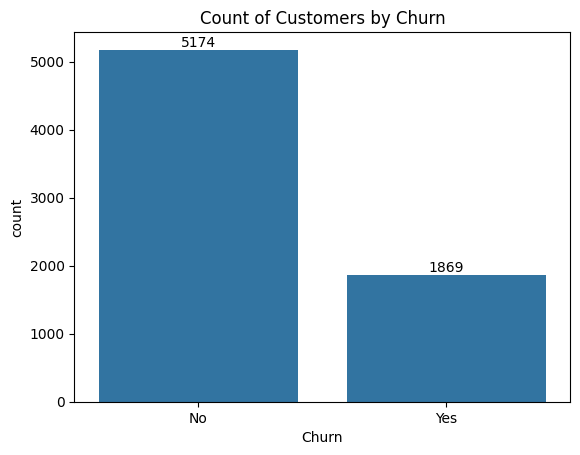

In [55]:
ax = sns.countplot(x = 'Churn' , data = df)

ax.bar_label(ax.containers[0]) 
plt.title("Count of Customers by Churn")
plt.show()

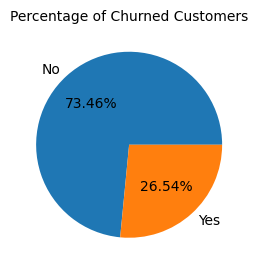

In [54]:
plt.figure(figsize = (3,4))
gb = df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'], labels = gb.index, autopct = "%1.2f%%")
plt.title("Percentage of Churned Customers", fontsize = 10)
plt.show()

In [57]:
# from the given pie chart we caan cnclude that 26.54% of our customers have churned out 
# not let's explore the reason behind it

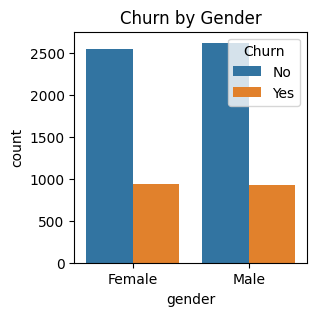

In [71]:
plt.figure(figsize = (3,3))
sns.countplot(x = "gender", data = df, hue = 'Churn')
plt.title("Churn by Gender")
plt.show()

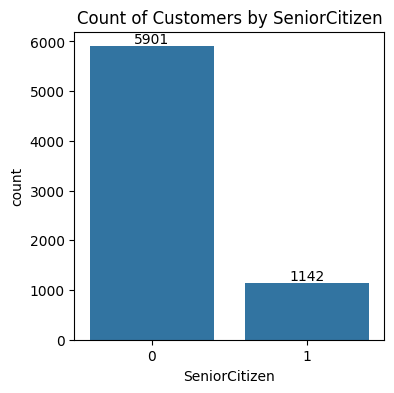

In [78]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = "SeniorCitizen", data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by SeniorCitizen")
plt.show()

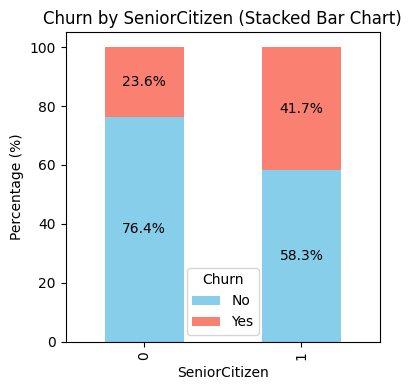

In [75]:
# Count data
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'])

# Convert to % of total within each SeniorCitizen category
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# Plot
ax = ct_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(4,4),
    color=['skyblue', 'salmon']
)

# Add percentage labels
for container in ax.containers:
    labels = [
        f'{v:.1f}%' if v > 0 else ''
        for v in container.datavalues
    ]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=10)

plt.title("Churn by SeniorCitizen (Stacked Bar Chart)")
plt.xlabel("SeniorCitizen")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

#  comparatively a greater percentage of people in senior citizen category have churned

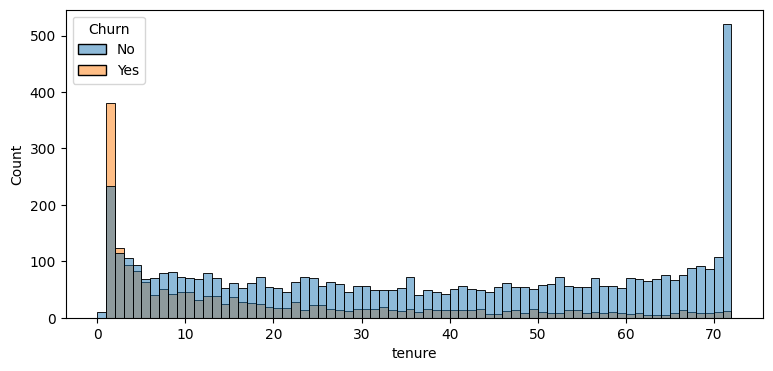

In [84]:
plt.figure(figsize = (9,4))
sns.histplot(x = "tenure", data = df, bins = 72, hue = "Churn")
plt.show()

# people who have used our services for a long time stayed and people who have used our services #1 or 2 months have churned

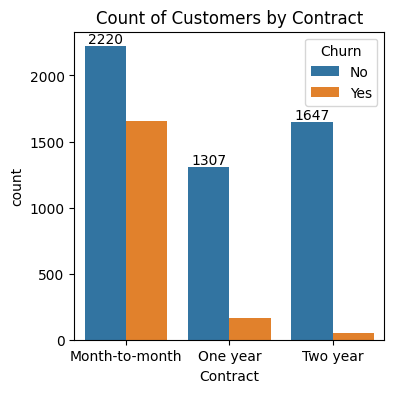

In [86]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = "Contract", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract")
plt.show()

# people who have month to month contract are likely to churn from those who have 1 or 2 years of contract

In [87]:
df.columns.values

<StringArray>
[      'customerID',           'gender',    'SeniorCitizen',
          'Partner',       'Dependents',           'tenure',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
   'MonthlyCharges',     'TotalCharges',            'Churn',
      'Totalharges']
Length: 22, dtype: str

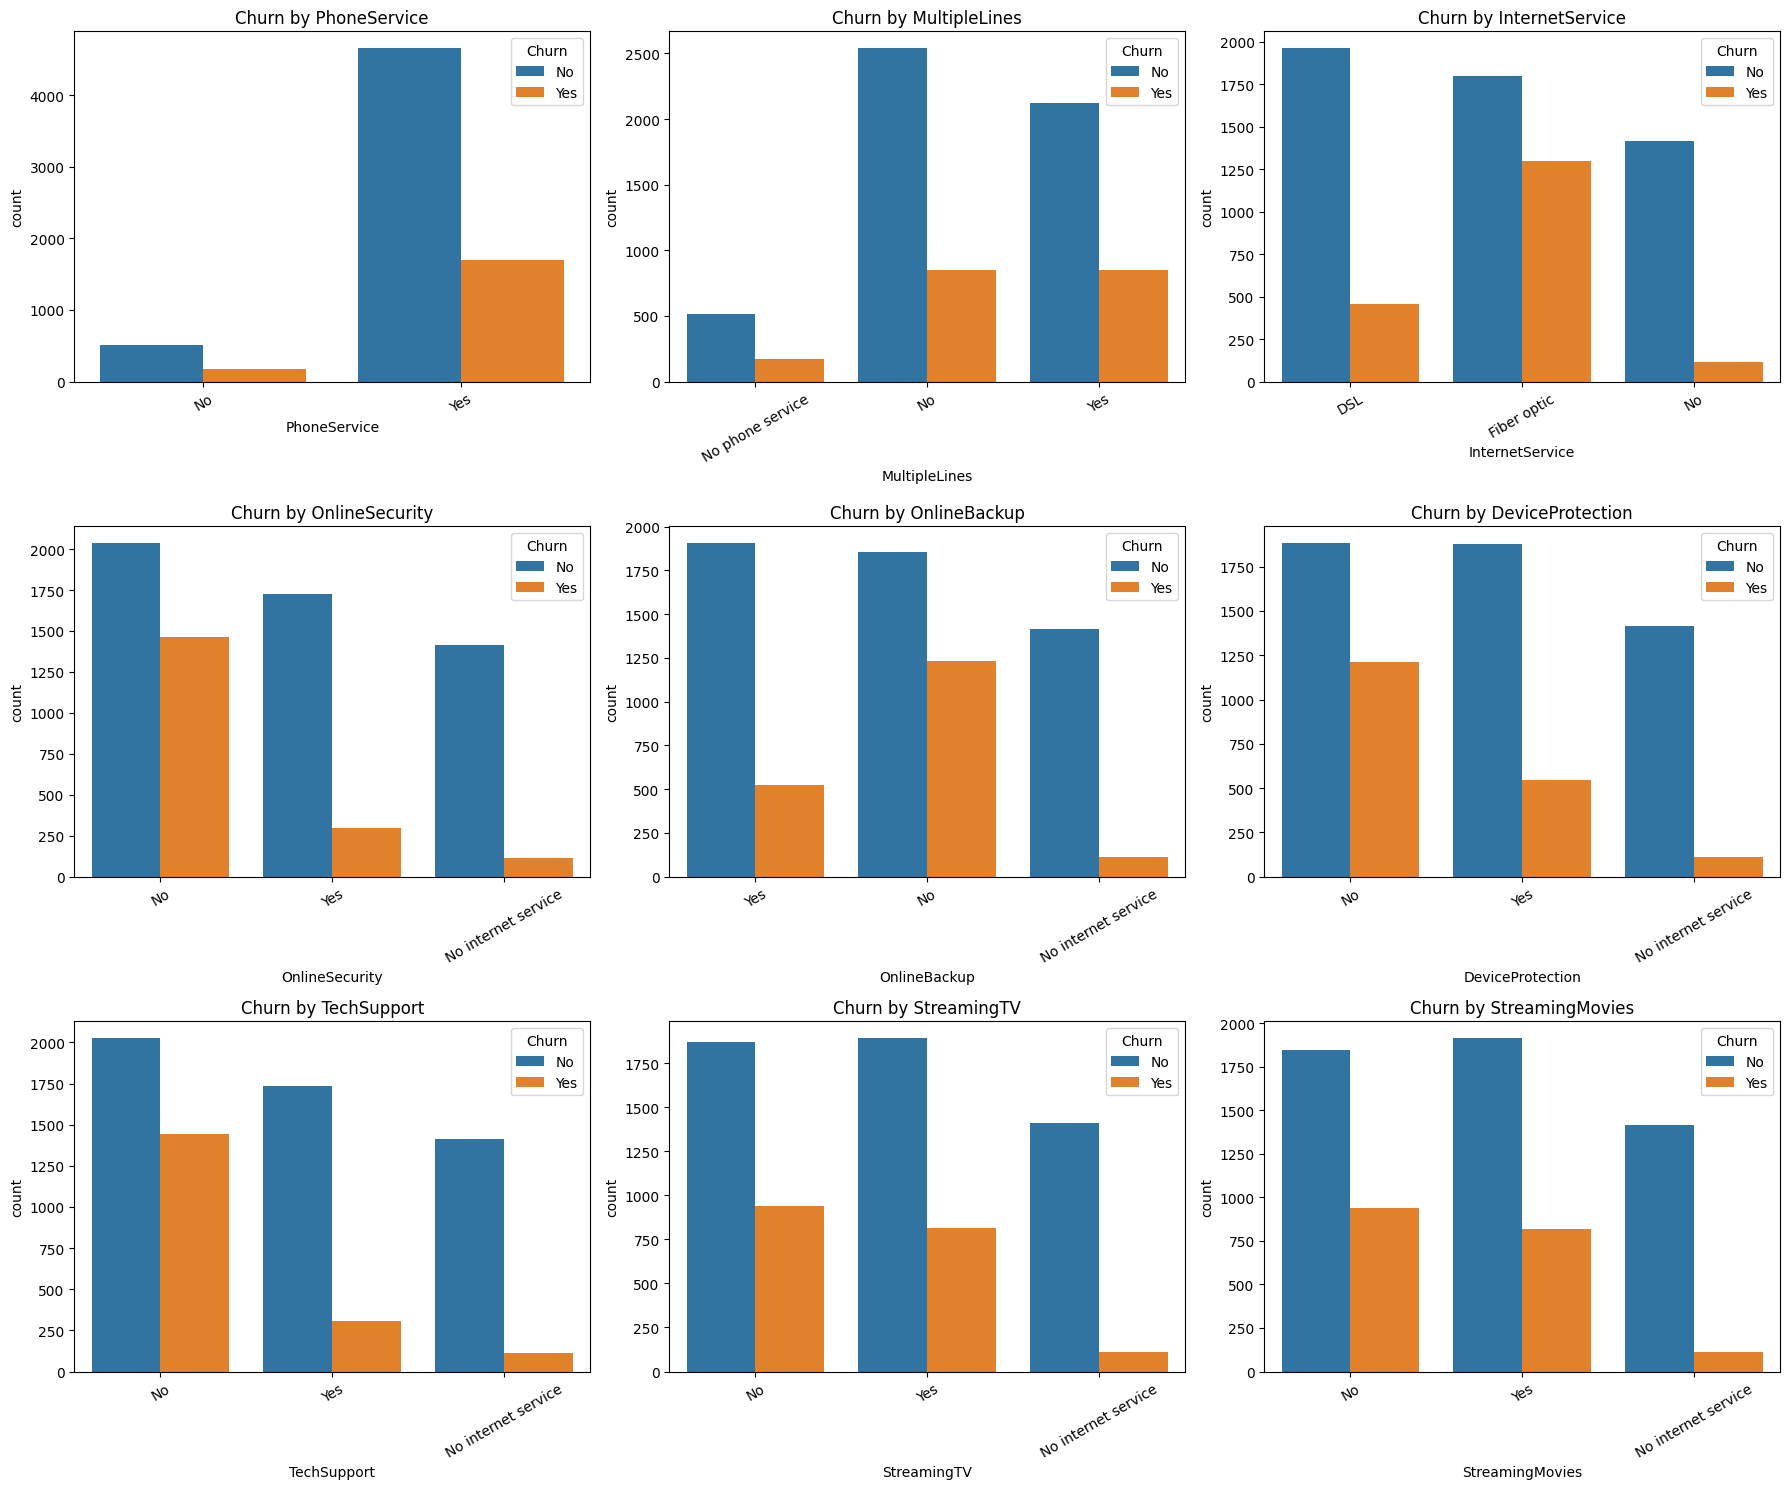

In [88]:
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    sns.countplot(data=df, x=col, hue='Churn', ax=ax)
    ax.set_title(f'Churn by {col}')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Churn')

plt.tight_layout()
plt.show()

Customers with fiber optic internet service exhibit the highest churn rate, while those with DSL or no internet service churn considerably less.
Subscribers who lack value-added services such as Online Security, Online Backup, Device Protection, and Tech Support show noticeably higher churn compared to customers who have these services.
Customers with Streaming TV and Streaming Movies display similar churn patterns regardless of subscription status, suggesting these entertainment services have a weaker relationship with churn.
Phone Service and Multiple Lines show only modest differences in churn, indicating they are less influential factors compared with internet-related services and support features.

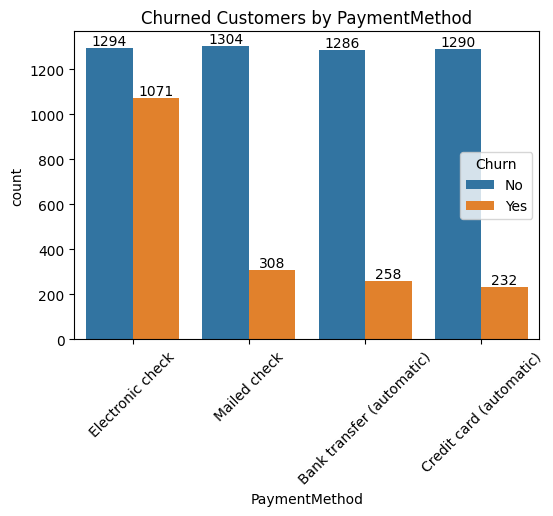

In [91]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = "PaymentMethod", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by PaymentMethod")
plt.xticks(rotation = 45)
plt.show()

#customer is likely to churn when he is using electronic check as a payment method.